# Land Use Classification from Satellite Images  

Group 4: Teresa Alvarez, Vikram Bhatt, Alessandro Cristofolini, Matteo Khoueiri, Dominique Robson, & Pengchong Zhao

---

## Executive Summary

In this project, we address the problem of land use classification using satellite image patches from the EuroSAT RGB dataset. The objective is to automatically classify land cover types (e.g., Forest, Residential, River, Industrial) from aerial imagery.

We compare two approaches:

1. A classical computer vision baseline using HOG features and a linear SVM.
2. A deep learning approach using transfer learning with a pretrained Convolutional Neural Network (CNN).


----
# 1. Business / Research Question

## Problem

Can satellite image patches be automatically classified into land use categories to support environmental monitoring and urban planning?

## Motivation

Manual annotation of satellite imagery is costly and time-consuming. Automated classification can:

- Accelerate large-scale analysis
- Support planning and monitoring
- Flag uncertain cases for human review

The system is intended as decision support rather than full automation.

In [ ]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 2. Dataset

## 2.1 Source

We use the EuroSAT RGB dataset:

- ~27,000 satellite image patches
- 10 land use classes
- RGB format, 64×64 resolution
- Images organized in class-based folders

## 2.2 Classes

- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Each image represents a satellite patch labeled with its dominant land use type.

In [22]:
DATA_DIR = Path("img")

# Verificar que existe
if not DATA_DIR.exists():
    raise FileNotFoundError(f"{DATA_DIR} not found")

# Detectar clases (subcarpetas)
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print(f"Number of classes detected: {len(classes)}")
print("Classes:")
for c in classes:
    print("-", c)

Number of classes detected: 10
Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [23]:
image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    data.append({
        "class": cls,
        "num_images": len(images)
    })

df_counts = pd.DataFrame(data).sort_values("class")
total_images = df_counts["num_images"].sum()

print(df_counts)
print("\nTotal images:", total_images)

                  class  num_images
0            AnnualCrop        3000
1                Forest        3000
2  HerbaceousVegetation        3000
3               Highway        2500
4            Industrial        2500
5               Pasture        2000
6         PermanentCrop        2500
7           Residential        3000
8                 River        2500
9               SeaLake        3000

Total images: 27000


## 2.3 Visualization of classes

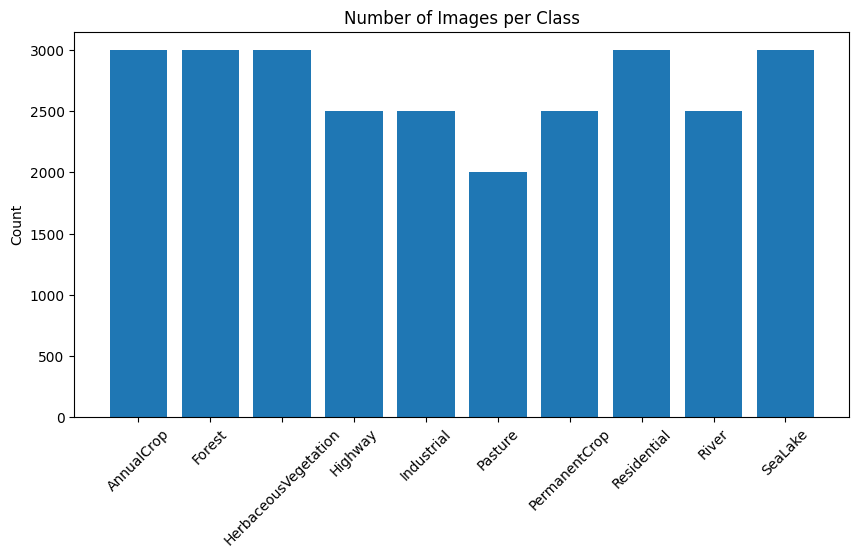

In [24]:
plt.figure(figsize=(10,5))
plt.bar(df_counts["class"], df_counts["num_images"])
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

## 2.4 Corrupted image check

No images are corrupter out of the 27000

In [25]:
corrupted = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    sample_images = random.sample(images, min(200, len(images)))
    
    for img_path in sample_images:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Number of corrupted images found:", len(corrupted))

Number of corrupted images found: 0


## Showing sample images

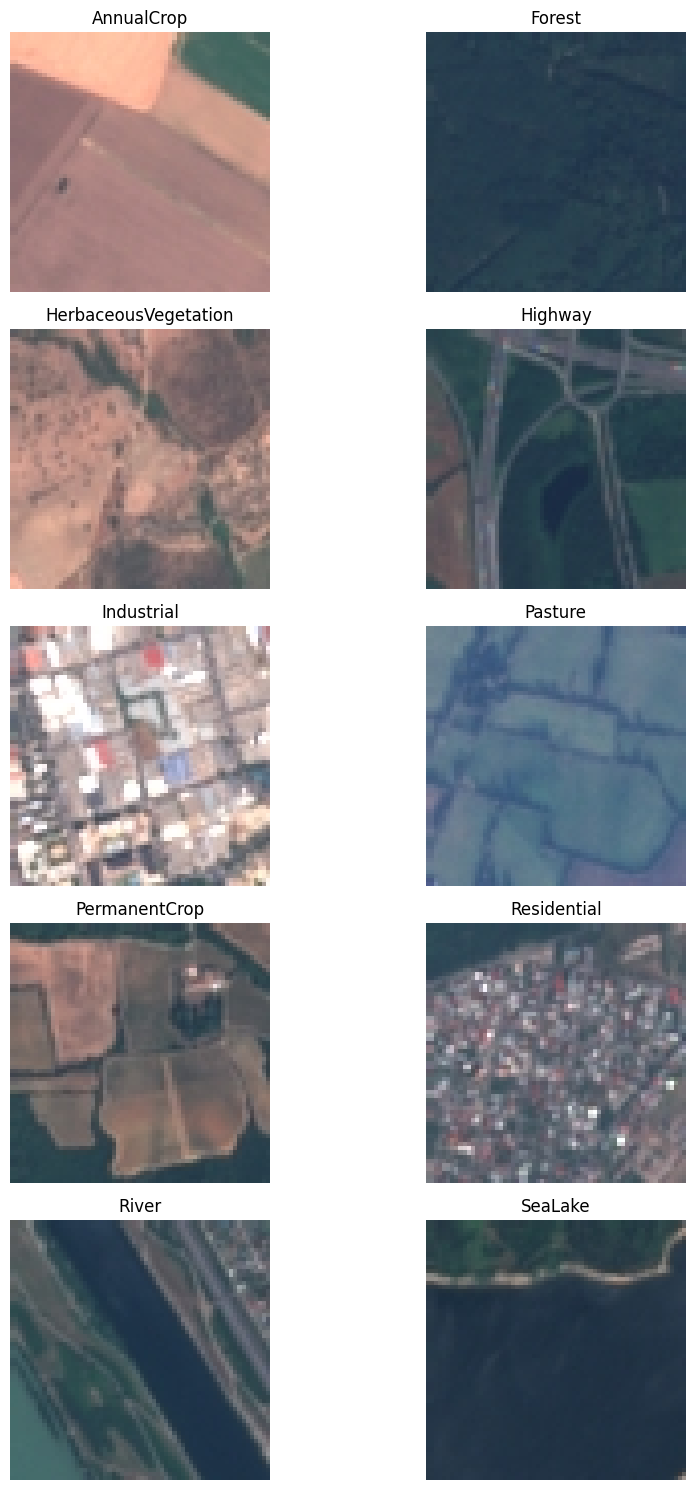

In [26]:
fig, axes = plt.subplots(5, 2, figsize=(10,15))

for ax, cls in zip(axes.flat, classes):
    sample_path = df_all[df_all["label"] == cls]["path"].sample(1).values[0]
    img = plt.imread(sample_path)
    
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2.5 Dataset Indexing

To prepare the dataset for model training, we construct a master DataFrame containing:

- The image file path
- The corresponding class label

This structured representation will allow us to perform a reproducible train/validation/test split while ensuring consistency across models.

In [27]:
all_data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    for img_path in images:
        all_data.append({
            "path": str(img_path),
            "label": cls
        })

df_all = pd.DataFrame(all_data)

print("Total images indexed:", len(df_all))
df_all.head()

#guardar dataframe por si acaso
df_all.to_csv("csv/image_data.csv", index=False)

Total images indexed: 27000


In [28]:
df_all["label"].value_counts()

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

# 3. Experimental Setup

## 3.1 Train / Validation / Test Split

The dataset is split into:

- 70% Training
- 15% Validation
- 15% Test

The split is stratified by class to preserve class balance.

A fixed random seed ensures reproducibility.

In [ ]:
#Codificar etiquetas a números
label_encoder = LabelEncoder()

df_all["label_encoded"] = label_encoder.fit_transform(df_all["label"])

num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)
print("Class mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Number of classes: 10
Class mapping:
0 -> AnnualCrop
1 -> Forest
2 -> HerbaceousVegetation
3 -> Highway
4 -> Industrial
5 -> Pasture
6 -> PermanentCrop
7 -> Residential
8 -> River
9 -> SeaLake


In [30]:
SEED = 42

#train vs temp (30% para temp)
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label_encoded"],
    random_state=SEED
)

# Dividir temp en validation (15%) y test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_encoded"],
    random_state=SEED
)

#verify size of splits
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 18900
Validation size: 4050
Test size: 4050


In [31]:
print("Train distribution:\n", train_df["label"].value_counts(normalize=True))
print("\nValidation distribution:\n", val_df["label"].value_counts(normalize=True))
print("\nTest distribution:\n", test_df["label"].value_counts(normalize=True))

Train distribution:
 label
Residential             0.111111
SeaLake                 0.111111
AnnualCrop              0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop           0.092593
Industrial              0.092593
Highway                 0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Validation distribution:
 label
SeaLake                 0.111111
HerbaceousVegetation    0.111111
Forest                  0.111111
AnnualCrop              0.111111
Residential             0.111111
Highway                 0.092593
Industrial              0.092593
PermanentCrop           0.092593
River                   0.092593
Pasture                 0.074074
Name: proportion, dtype: float64

Test distribution:
 label
SeaLake                 0.111111
AnnualCrop              0.111111
Residential             0.111111
Forest                  0.111111
HerbaceousVegetation    0.111111
PermanentCrop         

In [33]:
train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

df_splits = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

df_splits.head(),df_splits["split"].value_counts()

(                                   path        label  label_encoded  split
 0   img\Residential\Residential_238.jpg  Residential              7  train
 1          img\SeaLake\SeaLake_1784.jpg      SeaLake              9  train
 2  img\Residential\Residential_2621.jpg  Residential              7  train
 3     img\AnnualCrop\AnnualCrop_361.jpg   AnnualCrop              0  train
 4            img\Forest\Forest_1198.jpg       Forest              1  train,
 split
 train    18900
 val       4050
 test      4050
 Name: count, dtype: int64)

In [36]:
train_df.to_csv("csv/train_data.csv", index=False)
val_df.to_csv("csv/val_data.csv", index=False) 
test_df.to_csv("csv/test_data.csv", index=False)

df_splits.to_csv("csv/splits_data.csv", index=False)

## 3.2 Metrics functions

### Confusion matrix

In [37]:
def plot_confusion_matrix(y_true, y_pred, class_names, normalize=False):
    """
    Plots confusion matrix.
    
    Parameters:
    - y_true: true labels
    - y_pred: predicted labels
    - class_names: list of class names
    - normalize: if True, show percentages instead of raw counts
    """
    
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize else "d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Model evaluations

In [38]:
def evaluate_model(y_true, y_pred, class_names, model_name="Model"):
    """
    Computes and prints evaluation metrics.
    Returns dictionary with results.
    """
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    
    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {f1_macro:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion matrices
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=False)
    plot_confusion_matrix(y_true, y_pred, class_names, normalize=True)
    
    return {
        "model": model_name,
        "accuracy": acc,
        "macro_f1": f1_macro
    }

### Comparative table

In [39]:
def compare_models(results_list):
    """
    Creates comparison table from evaluation results.
    
    results_list: list of dictionaries returned by evaluate_model()
    """
    
    results_df = pd.DataFrame(results_list)
    results_df = results_df.set_index("model")
    
    print("\n===== Model Comparison =====")
    display(results_df)
    
    return results_df

## 4. Baseline Model: Random Forest